# Introduction
Images were sourced through manual verification of urls using:  
- https://www.kaggle.com/code/morescope/ur-human-label-sourcing/
- https://public.tableau.com/app/profile/paul.moresco/viz/reviewspecies/resultdf


In [1]:
# Data Handling
import pandas as pd

# IO - getting files and images
import requests
import json
import os
import urllib.parse

# For randomizing which images get downloaded
import random
from tqdm.auto import tqdm

# For model loading and fine tuning
from fastai.vision.all import *
from fastai.vision.widgets import *
import torch

print("==== Loaded Libraries ====")

==== Loaded Libraries ====


# Accessing observations (image labels) from the curated list

In [2]:
df = pd.read_csv('/kaggle/input/ur-source-image-urls/result df_data.csv')
df.head()

,scientificName (group),publicURL (copy)
0,Actitis macularius,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/101MEDIA/SYFW2898.JPG
1,Actitis macularius,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/101MEDIA/SYFW2882.JPG
2,Actitis macularius,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/101MEDIA/SYFW2872.JPG
3,Actitis macularius,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/101MEDIA/SYFW2846.JPG
4,Actitis macularius,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/101MEDIA/SYFW2782.JPG


In [7]:
# rename fields to consistent for this notebook
df = df.rename(columns={
    'scientificName (group)': 'scientificName',
    'publicURL (copy)': 'publicURL'
})

## Run without minimums to see if probability collapses - validation minimum should be minimum 1

In [ ]:
# Adjust as the project progresses:
n_obs_minimum = 26

In [8]:
# Show the results
with pd.option_context('display.width', 0, 'display.max_colwidth', None):
    display(df.head())
    
print(f'Total rows: {len(df)}\n')
print(df['scientificName'].value_counts())

,scientificName,publicURL
0,Actitis macularius,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/101MEDIA/SYFW2898.JPG
1,Actitis macularius,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/101MEDIA/SYFW2882.JPG
2,Actitis macularius,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/101MEDIA/SYFW2872.JPG
3,Actitis macularius,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/101MEDIA/SYFW2846.JPG
4,Actitis macularius,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/101MEDIA/SYFW2782.JPG


Total rows: 614

scientificName
Larus delawarensis & Larus smithsonianus         54
Sturnus vulgaris                                 42
Procyon lotor                                    37
Castor canadensis                                37
Turdus migratorius                               36
Sylvilagus floridanus                            34
Canis familiaris                                 33
Ardea herodias                                   32
Actitis macularius                               30
blank                                            30
Anas platyrhynchos                               27
Rattus norvegicus                                26
Passer domesticus                                25
Nycticorax nycticorax                            25
Branta canadensis                                24
Apalone spinifera & Trachemys scripta elegans    22
Canis latrans                                    18
Felis catus                                      17
Didelphis virginiana            

### We're left with 610 rows for 27 classifications 
includes dogs and blanks - we previously only did 10 classifications with min images = 26

# Downloading Images that meet the criteria
Passing our filtered df to the s3 bucket to request images in grouped train or test splits

In [9]:
# Create the directories
base_dir = '/kaggle/working/images'
test_dir = '/kaggle/working/_tests'
os.makedirs(test_dir, exist_ok=True)

grouped = list(df.groupby('scientificName'))

In [10]:
# Show the structure of the grouped list for understanding
print("speciesName: ", grouped[0][0])
print("dataframe: ")
grouped[0][1].head()

speciesName:  Actitis macularius
dataframe: 


,scientificName,publicURL
0,Actitis macularius,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/101MEDIA/SYFW2898.JPG
1,Actitis macularius,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/101MEDIA/SYFW2882.JPG
2,Actitis macularius,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/101MEDIA/SYFW2872.JPG
3,Actitis macularius,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/101MEDIA/SYFW2846.JPG
4,Actitis macularius,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/101MEDIA/SYFW2782.JPG


## Grouped is a list where each index species has a dataframe  so key, value is scientific_name, df of images

/kaggle/working/images/Actitis_macularius/2024-06-27_ur011_syfw2898.jpg


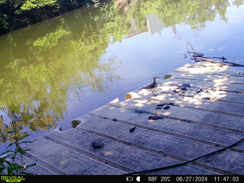

In [23]:
# fast ai version of image downloading
from fastdownload import download_url

ims = grouped[0][1]['publicURL'].tolist()
imn = [f"{url.split('/')[-4].lower()}_{url.split('/')[-1].rsplit('.', 1)[0].lower()}" for url in ims]
imn = [name.removesuffix('.JPG').removesuffix('.jpg') for name in imn] # standardize imn

len(ims)

# Might cause some renaming issues if 
dest = os.path.join(base_dir, grouped[0][0].replace(' ','_'), f'{imn[0]}.jpg')
print(dest)

download_url(ims[0], dest)

im = Image.open(dest)
im.to_thumb(244,244)

Clearly some issues with single species including multiple species - we've seen this before and it will require some cleaning.

In [24]:
# For cleanup while testing
!rm /kaggle/working/images/* -rf

In [27]:
%%time
# fast ai version of all images downloading - drops the mediaID from the pipeline which might be ok
for species, group in grouped:
    group = group.dropna(subset=['publicURL'])

    n_split = len(group) - 1
    train_samples = group.iloc[:n_split]
    test_sample = group.iloc[n_split]

    train_urls = train_samples['publicURL'].tolist()
    test_url = test_sample['publicURL']
    
    
    species_folder = species.replace(' ', '_')
    species_dir = os.path.join(base_dir, species_folder)
    
    download_images(species_dir, urls=train_urls)
    print(species_dir)
    
    # Download test image
    test_image_path = os.path.join(test_dir, f'{species_folder}.JPG')
    download_url(test_url, test_image_path)

print("==== Downloaded Images ====")
    

/kaggle/working/images/Actitis_macularius


/kaggle/working/images/Agelaius_phoeniceus


/kaggle/working/images/Anas_platyrhynchos


/kaggle/working/images/Apalone_spinifera_&_Trachemys_scripta_elegans


/kaggle/working/images/Ardea_herodias


...

/kaggle/working/images/Sylvilagus_floridanus


/kaggle/working/images/Turdus_migratorius


/kaggle/working/images/Zonotrichia_albicollis


/kaggle/working/images/blank


==== Downloaded Images ====
CPU times: user 13.8 s, sys: 10.7 s, total: 24.4 s
Wall time: 56.9 s


In [28]:
# validate images
fns = get_image_files(base_dir)
failed = verify_images(fns)
print(failed)
failed.map(Path.unlink);

[]


# For each image downloaded we are going to interact with fastai
Dataloaders (dls) are tensors that fastai simplifies for use in model fine-tuning.  
The library loads only what's needed (even though we passed * at the top) and has some built in common features.  

We're planning on using resnet18 - so we want to resize to 224x224 - and want to use aug_transforms() to get some visual variation in images from cameratraps.  
This means that at each pass of the dls to the fine tuning system the model will see slightly different images so it learns how to detect with some variation.

==== Loading images into tensors ====

CPU times: user 15 s, sys: 11 s, total: 26 s
Wall time: 25.6 s


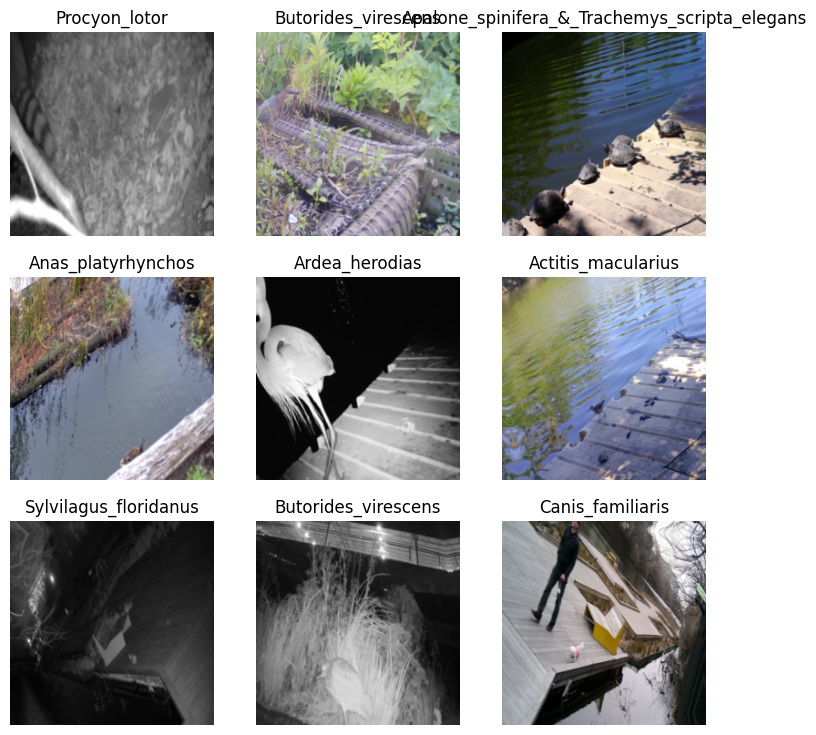

In [29]:
%%time
print('==== Loading images into tensors ====\n')
from sklearn.model_selection import train_test_split

path = Path('/kaggle/working/images')

# Stratified split to balance classes in train/valid sets
def stratified_splitter(items):
    labels = [parent_label(i) for i in items]
    train_idx, valid_idx = train_test_split(
        range(len(items)),
        test_size=0.2,
        stratify=labels,
        random_state=42
    )
    return train_idx, valid_idx

# Custom image trimming class
class CropTopBottom(Transform):
    def __init__(self, top_pct=0.1, bottom_pct=0.1):
        self.top_pct = top_pct
        self.bottom_pct = bottom_pct

    def encodes(self, img: PILImage):
        w, h = img.size
        top = int(h * self.top_pct)
        bottom = int(h * (1 - self.bottom_pct))
        return img.crop((0, top, w, bottom))

# DataBlock with custom splitter - removed batch transforms because the center zoom was cropping animals
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    get_y=parent_label,
    splitter=stratified_splitter,
    item_tfms=[CropTopBottom(top_pct=0.1, bottom_pct=0.1), Resize(224, method='squish')],
    batch_tfms=aug_transforms()
)

# Build DataLoaders
dls = dblock.dataloaders(path)

# Show sample batch
dls.show_batch(max_n=9)

Now when resizing we aren't cutting off animals not centered and aren't introducing new zero padded areas.

# Fine tuning pre-trained models to our classifications
Initially we downloaded the resnet 18 model and fine tuned with 5 epochs to our dataset.  
Images , tests, and data are organized in folders and loaded into dls as appropriate.  

# Seeing what models are best
https://www.kaggle.com/code/morescope/which-image-models-are-best/

In [30]:
import timm
timm.list_models('convnext*')

['convnext_atto',
 'convnext_atto_ols',
 'convnext_atto_rms',
 'convnext_base',
 'convnext_femto',
 'convnext_femto_ols',
 'convnext_large',
 'convnext_large_mlp',
 'convnext_nano',
 'convnext_nano_ols',
 'convnext_pico',
 'convnext_pico_ols',
 'convnext_small',
 'convnext_tiny',
 'convnext_tiny_hnf',
 'convnext_xlarge',
 'convnext_xxlarge',
 'convnext_zepto_rms',
 'convnext_zepto_rms_ols',
 'convnextv2_atto',
 'convnextv2_base',
 'convnextv2_femto',
 'convnextv2_huge',
 'convnextv2_large',
 'convnextv2_nano',
 'convnextv2_pico',
 'convnextv2_small',
 'convnextv2_tiny']

In [31]:
%%time
learn = vision_learner(dls, 'convnext_tiny', metrics=error_rate)

if torch.cuda.is_available():
    learn.model = learn.model.cuda()
    print("Using:", next(learn.model.parameters()).device)  # should print 'cuda:0'
else:
    learn.model = learn.model.cpu()
    print("Using CPU")

# For this version we're trying 10 epochs
learn.fine_tune(5)

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Using CPU


epoch,train_loss,valid_loss,error_rate,time


KeyboardInterrupt: 

We went from 78 to 92% accuracy switching from resnet18 to convnext_tiny

## Confusion Matrix

In [ ]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

Considerably better error rates on our dog, duck, and sandpiper categories
But now blanks are not being labeled well.  

This is ok - we're alright with a high false positive rate (meaning it's actually blank, but there might be an animal worth looking for?)

## Testing a single image prediction
Here we'll look at our test for a beaver and see if the model can predict it correctly.

In [ ]:
image_path = '/kaggle/working/_tests/Castor_canadensis.JPG'
pred, pred_idx, probs = learn.predict(PILImage.create(image_path))


PILImage.create(image_path).show(title=f"Probably: {pred} ({probs[pred_idx]:.2f})")

## Tabular predictions for all images in the folder

In [ ]:
# Predicting in a table for each image
test_path = Path("/kaggle/working/_tests")
test_files = get_image_files(test_path)

results = []
for f in test_files:
    pred_class, pred_idx, pred_probs = learn.predict(f)
    results.append({
        'file': f.name,
        'pred_class': str(pred_class),
        'probability': float(pred_probs[pred_idx]),
        'top3': [
            (learn.dls.vocab[i], format(float(pred_probs[i]), ".4f"))
            for i in pred_probs.argsort(descending=True)[:3]
        ]
    })

results_df = pd.DataFrame(results)
display(results_df)

## A pretty prediction plot for 9 of the test images

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
axes = axes.flatten()

for ax, img_file in zip(axes, test_files):
    img = PILImage.create(img_file)
    pred_class, pred_idx, pred_probs = learn.predict(img)

    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Picture of: {img_file.name}\nPredicted: {pred_class} ({pred_probs[pred_idx]:.1%})", fontsize=9)

# Hide unused subplots if fewer than 9 images
for ax in axes[len(test_files):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

# Exporting the fine tuned model

In [ ]:
# export the model for futher use
learn.export('/kaggle/working/2025-06-20-convnet_tinyx25p-v11.pkl')